# Benchmark 1D 

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
from generalization import Neural_network, MultiFidelity

from cuqi.distribution import Uniform, Gaussian,JointDistribution
from cuqi.sampler import MH, NUTS
from cuqi.model import Model
from cuqi.geometry import Continuous1D, Discrete
import keras

# Creation of the model

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

HPO = False

#Benchmark1
highfid = lambda x: (6.*x-2.)**2*np.sin(12.*x-4.)
lowfid  = lambda x: 0.5*highfid(x) + 10*(x-0.5) + 5.
Nhf = 5
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

NepoLF = 1000
NepoHF = 500

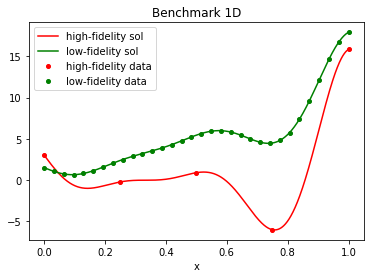

In [3]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [4]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)


## High fidelity model

In [5]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

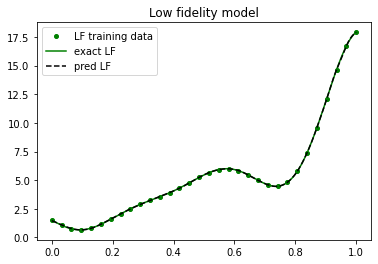

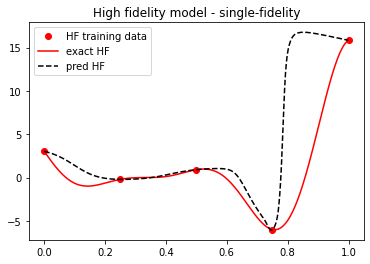

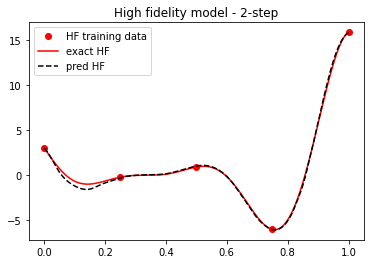

In [7]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [16]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = np.array([400,800,1200])  # Number of samples
proposal_sds = np.array([3.]) # Standard deviation for the proposal distribution
chain_length=4


In [17]:
# from cuqi.problem import BayesianProblem
# A=Model(forward=modelLF.prediction,range_geometry=Continuous1D(5),domain_geometry=Continuous1D(5))
# x=Uniform(np.zeros(5),np.ones(5))
# y=Gaussian(mean=A(x),cov=proposal_sds[0])
# y_obs=y(x=real_x).sample()
# posterior=JointDistribution(y,x)(y=y_obs)
# BP=BayesianProblem(y,x).set_data(y=y_obs)
# BP.UQ()

### Low Fidelity

********************  # Variance = 3.0  ********************
********************  # Steps = 400  ********************


Sample 400 / 400

Average acceptance rate: 0.185 MCMC scale: 0.07895144519042689 

********************  # Mean values = [0.43147592 0.48157903 0.27668286 0.56417049 0.90017689]  ********************
Sample 400 / 400

Average acceptance rate: 0.215 MCMC scale: 0.05701081846109457 

********************  # Mean values = [0.26189159 0.34628731 0.51098861 0.44060256 0.90242057]  ********************
Sample 400 / 400

Average acceptance rate: 0.215 MCMC scale: 0.06978198753594404 

********************  # Mean values = [0.41314356 0.32840483 0.45501906 0.50381686 0.90017362]  ********************
Sample 400 / 400

Average acceptance rate: 0.18 MCMC scale: 0.08187855879863128 

********************  # Mean values = [0.36038807 0.2959309  0.47531535 0.56849685 0.86920518]  ********************


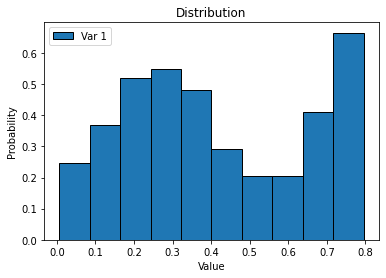

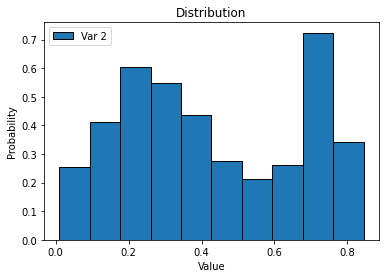

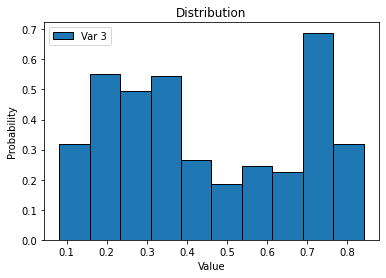

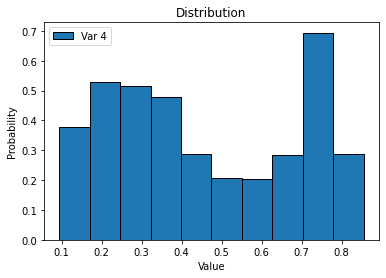

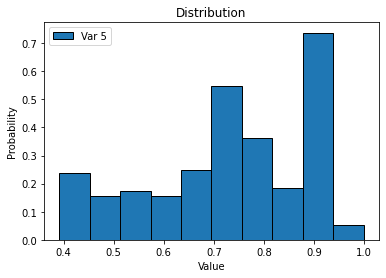

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 5.628387712752303  ********************
[[ 6.71867921e-02  6.61515158e-02  6.51420365e-02  6.41601159e-02
   6.31776188e-02  6.21564870e-02  6.11878594e-02  6.01896714e-02
   5.90871707e-02  5.79318370e-02  5.69184141e-02  5.58439200e-02
   5.48354181e-02  5.38465011e-02  5.28651348e-02  5.18512221e-02
   5.08170728e-02  4.98645650e-02  4.88456667e-02  4.77139497e-02
   4.66348558e-02  4.56011525e-02  4.46303412e-02  4.36592110e-02
   4.27642206e-02  4.18971343e-02  4.09476174e-02  4.00654964e-02
   3.92443665e-02  3.82979286e-02  3.73986966e-02  3.64058503e-02
   3.53964010e-02  3.44810426e-02  3.36327692e-02  3.27728035e-02
   3.17838341e-02  3.07963006e-02  2.98709809e-02  2.88966377e-02
   2.79628409e-02  2.70190512e-02  2.61001018e-02  2.50926104e-02
   2.40390532e-02  2.30653692e-02  2.20605662e-02  2.10635598e-02
   2.00279982e-02  1.89505323e-02  1.78725391e-02  1.67321637e-02
   1.57480945e-02  1.48021617e-02  1.38046394e-02  1.30812436e-02

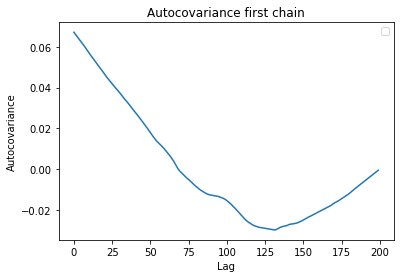

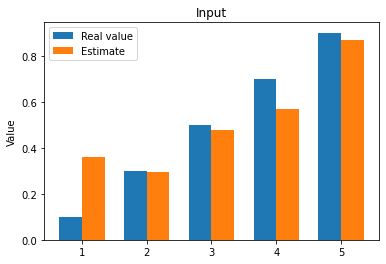

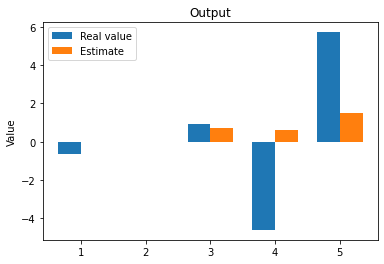

********************  # Variance = 3.0  ********************
********************  # Steps = 800  ********************
Sample 800 / 800

Average acceptance rate: 0.17833333333333334 MCMC scale: 0.06970201089568961 

********************  # Mean values = [0.13487711 0.52855741 0.64573803 0.61057232 0.90513621]  ********************
Sample 800 / 800

Average acceptance rate: 0.18833333333333332 MCMC scale: 0.07525147420974002 

********************  # Mean values = [0.14666864 0.54123211 0.63295317 0.66049463 0.902444  ]  ********************
Sample 800 / 800

Average acceptance rate: 0.21166666666666667 MCMC scale: 0.08192232053598557 

********************  # Mean values = [0.14843702 0.56449675 0.61415599 0.63113361 0.90090362]  ********************
Sample 800 / 800

Average acceptance rate: 0.18666666666666668 MCMC scale: 0.07762789088336328 

********************  # Mean values = [0.14134087 0.57261339 0.62855586 0.63138112 0.89957491]  ********************


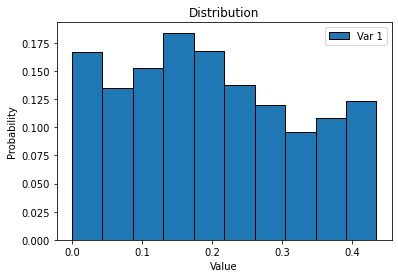

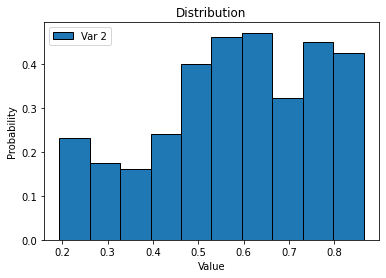

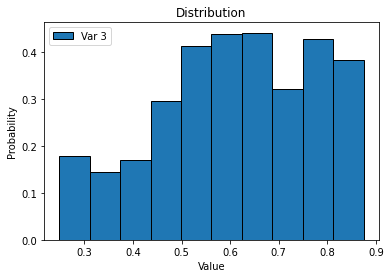

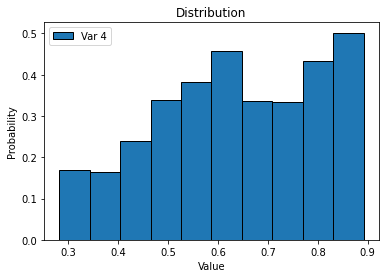

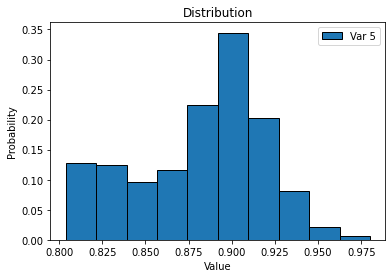

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 78.05461896925125  ********************
[[ 4.96043058e-03  4.58725426e-03  4.24934862e-03 ... -6.16232000e-06
  -1.26915459e-06  3.62401081e-06]
 [ 5.37772132e-03  4.86091886e-03  4.41458311e-03 ...  3.20941040e-05
   2.46294644e-05  1.71648247e-05]
 [ 1.06444201e-02  1.00554277e-02  9.48338699e-03 ... -7.00120343e-06
  -1.72800194e-05 -1.48341837e-05]
 [ 8.85457335e-03  8.27304534e-03  7.75195479e-03 ... -1.97604810e-05
  -1.31736540e-05 -6.58682701e-06]]


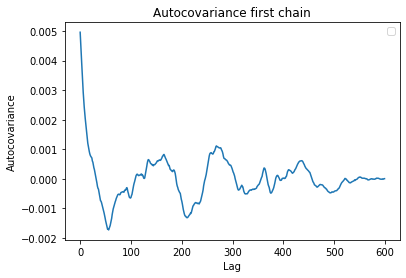

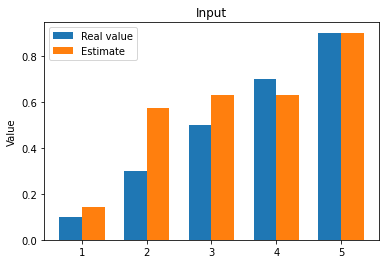

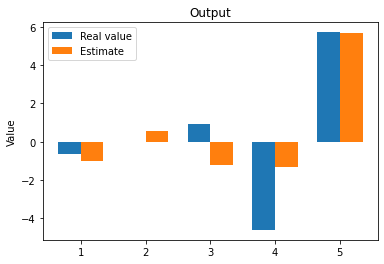

********************  # Variance = 3.0  ********************
********************  # Steps = 1200  ********************
Sample 228 / 1200

KeyboardInterrupt: 

In [18]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )
        

        estimates=modelLF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        
        

In [ ]:
# from scipy.interpolate import interp1d
# # rendila un decorator
# def estimate_gradient(x, y, new_value_x):
#     """
#     Calcola una stima del gradiente nei punti specificati dati gli array x e y.

#     Parametri:
#     - x: array NumPy contenente le coordinate x dei dati.
#     - y: array NumPy contenente le coordinate y dei dati.
#     - punti: array NumPy contenente i punti in cui si vuole stimare il gradiente.

#     Ritorna:
#     - gradiente: array NumPy contenente le stime del gradiente nei punti specificati.
#     """

#     # Verifica che le dimensioni di x e y siano uguali
#     if x.shape != y.shape:
#         raise ValueError("Le dimensioni di x e y devono essere uguali.")

#     # Calcola la derivata rispetto a x
#     dx = np.gradient(x)

#     # Calcola la derivata rispetto a y
#     dy = np.gradient(y)

#     # Calcola il gradiente come rapporto tra le derivate rispetto a x e y
#     gradiente = dy / dx

#     # Utilizza la funzione np.interp per stimare il gradiente nei punti specificati
#     gradiente_stimato = np.interp(new_value_x, x, gradiente)

#     return gradiente_stimato


# def gradient_LF(value):
    
#     return estimate_gradient(x_test,yLF,value)

In [ ]:
# # Introduction of the model and of the first step


# # ATTENZIONE!  in caso LF non si dovrebbe mettere comunque forward=modelHF?
# A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# num_bins = 10

# for sd in proposal_sds:
#     print(                f"********************  # Variance = {sd}  ********************"
#                 )
    
#     # prior 
#     y_LF=Gaussian(mean=A_LF(x_LF),cov=sd)
#     y_obs=y_LF(x_LF=real_x).sample()
#     posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
#     x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

#     for N in n_samples:
#         print(                f"********************  # Steps = {N}  ********************"
#                 )
#         # Sampler, here Metropolis hastings
#         MHsampler_LF=MH(posterior_LF,x0=x_init)
        
#         estimates=np.empty((x_init.shape[0],0))
#         chains=np.empty((0,x_init.shape[0],N))
#         post=np.empty((x_init.shape[0],0))
        
#         for i in range(chain_length):
#                 samplesMH_LF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#                 estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
#                 # chains=np.concatenate(chains, samplesMH_LF.samples)
#                 chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

#                 post=np.concatenate((post,samplesMH_LF.samples),axis=1)
        
#         print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
#                 )
          
#         for num in range(post.shape[0]):        
#                 bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
#                 hist, _ = np.histogram(post, bins=bin_edges)
#                 hist=hist/post.shape[1]
#                 bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#                 plt.figure()
#                 plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

#                 plt.xlabel('Value')
#                 plt.ylabel('Probability')
#                 plt.title('Distribution')
#                 plt.legend()
#                 plt.show()
                
#                 # plt.figure()
#                 # plt.plot(np.mean(chains,axis=(0,2)))
#                 # plt.xlabel('Step')
#                 # plt.title(f'Averaged chain var {num+1}')
#                 # plt.show()

                
                
                
# # samplesMH_LF.plot_trace()
# # print("mean value")
# # print(samplesMH_LF.mean())
# # print("ESS")
# # print(samplesMH_LF.compute_ess())
# # samplesMH_LF.plot_autocorrelation()

c:\Users\Giacomo\Desktop\PACS_codice\pacs_new\PACS_project2\1DBench_MCMC\generalization.py:130: UserWarning: No observation nor data given
  warnings.warn(warning_message, UserWarning)


UnboundLocalError: local variable 'dim' referenced before assignment

#### prova hmc

In [ ]:
#from cuqi.distribution import Beta

In [ ]:
# real_x = np.array([0.1,0.3,0.5,0.7,0.9])
# observed_output = highfid(real_x)

# # Set parameters for the MCMC
# n_samples = np.array([10,800,1200])  # Number of samples
# initial_x = 0.5 # Initial value for x
# proposal_sds = np.array([0.1,0.25,0.5,0.75,1.]) # Standard deviation for the proposal distribution
# chain_length=2

********************  # Variance = 0.1  ********************
********************  # Steps = 10  ********************


Sample 15 / 15
Sample 15 / 15
********************  # Mean values = [0.30188455 0.44248868 0.46951089 0.51347088 0.54969043]  ********************


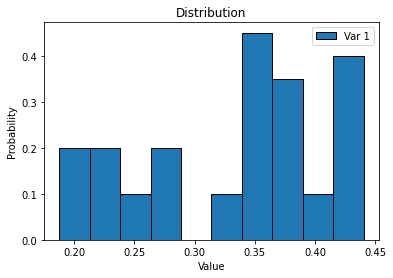

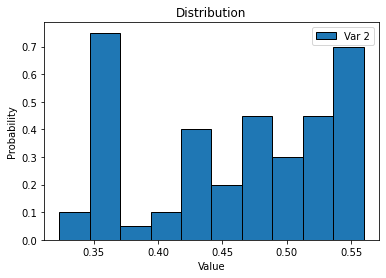

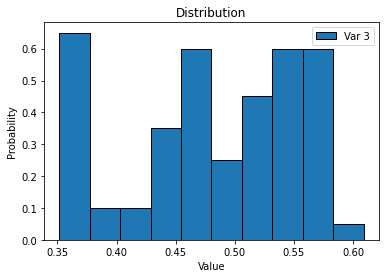

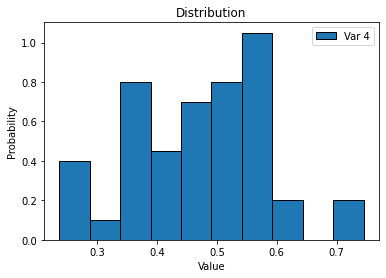

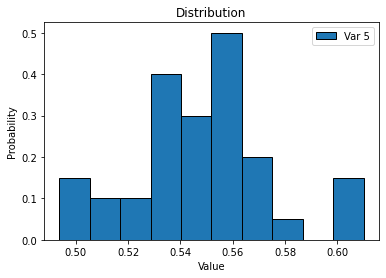

********************  # Steps = 800  ********************
Sample 1200 / 1200
Sample 1200 / 1200
********************  # Mean values = [0.48887202 0.48154788 0.48417455 0.48368852 0.49635091]  ********************


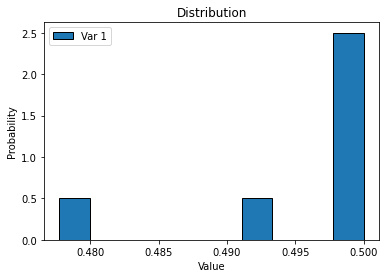

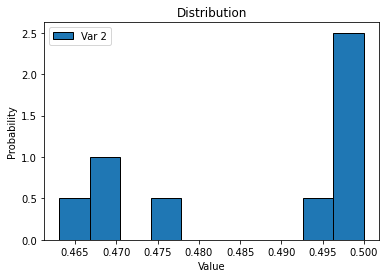

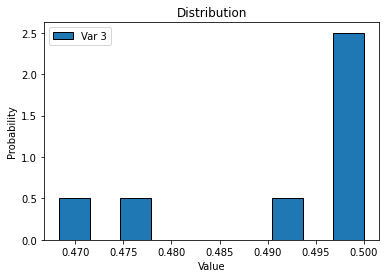

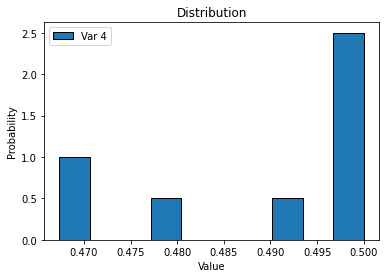

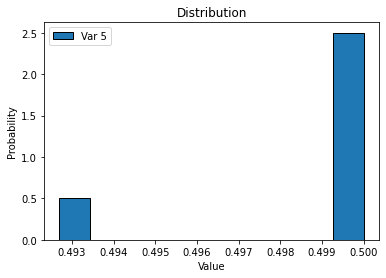

********************  # Steps = 1200  ********************
Sample 1800 / 1800


KeyboardInterrupt: 

In [ ]:
# A_LF=Model(forward=modelLF.prediction, jacobian=gradient_LF,range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Beta(alpha=2*np.ones(5),beta=2*np.ones(5))  # <------
# num_bins = 10

# for sd in proposal_sds:
#     print(                f"********************  # Variance = {sd}  ********************"
#                 )
#     y_LF=Gaussian(mean=A_LF(x_LF),cov=sd)
#     y_obs=y_LF(x_LF=real_x).sample()
#     posterior_LF=JointDistribution(y_LF,x_LF)(y_LF=y_obs)
#     x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

#     for N in n_samples:
#         print(                f"********************  # Steps = {N}  ********************"
#                 )
#         MHsampler_LF=NUTS(posterior_LF,x0=x_init)
#         estimates=np.empty((x_init.shape[0],0))
#         chains=np.empty((0,x_init.shape[0],N))
#         post=np.empty((x_init.shape[0],0))
#         for i in range(chain_length):
#                 samplesMH_LF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#                 estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
#                 # chains=np.concatenate(chains, samplesMH_LF.samples)
#                 chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

#                 post=np.concatenate((post,samplesMH_LF.samples),axis=1)
        
#         print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
#                 )
          
#         for num in range(post.shape[0]):        
#                 bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
#                 hist, _ = np.histogram(post, bins=bin_edges)
#                 hist=hist/post.shape[1]
#                 bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#                 plt.figure()
#                 plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

#                 plt.xlabel('Value')
#                 plt.ylabel('Probability')
#                 plt.title('Distribution')
#                 plt.legend()
#                 plt.show()
                
#                 # plt.figure()
#                 # plt.plot(np.mean(chains,axis=(0,2)))
#                 # plt.xlabel('Step')
#                 # plt.title(f'Averaged chain var {num+1}')
#                 # plt.show()

                
                
                
# # samplesMH_LF.plot_trace()
# # print("mean value")
# # print(samplesMH_LF.mean())
# # print("ESS")
# # print(samplesMH_LF.compute_ess())
# # samplesMH_LF.plot_autocorrelation()

In [ ]:
# #proposal_sd=np.exp(-(d-y_obs)**2/(np.sqrt(2*0.3)))

# A_LF=Model(forward=modelLF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_LF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))

# d=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))

# y_LF=Gaussian(A_LF(x_LF),lambda d: np.exp(-(d-modelHF.prediction(real_x))**2/(np.sqrt(2*0.3))))      # ATTENZIONE! NON SO SE SENSATO METTERE QUA PREDICTION, A QUEL PUNTO RUOLO DI y_obs sotto? E poi, si deve valutare NN(x_step) o  NN(real_x)?
# y_obs=y_LF(x_LF=real_x, d=0.1*np.ones(5)).sample()    # d=modelLF.prediction(real_x)
# posterior_LF=JointDistribution(y_LF,x_LF,d)(y_LF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])
# MHsampler_LF = MH(posterior_LF, x0=x_init)   #x0=np.vstack(x_init, modelLF.prediction(x_init)

# estimates=np.empty((x_init.shape[0],0))
# chains=np.empty((0,x_init.shape[0],n_samples))

# chain_length=8
# n_samples=600
# for i in range(chain_length):
#     samplesMH_LF=MHsampler_LF.sample_adapt(n_samples,int(n_samples/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#     estimates=np.column_stack((estimates,samplesMH_LF.mean()[:, np.newaxis]))
#     # chains=np.concatenate(chains, samplesMH_LF.samples)
#     chains = np.concatenate((chains, np.expand_dims(samplesMH_LF.samples, axis=0)), axis=0)

    
# print(samplesMH_LF.mean().shape)    
# print(estimates)
# print(estimates.shape)
# print(chains.shape)    

# print("MEAN VALUES")
# print(estimates.mean(axis=1))

# # samplesMH_LF.plot_trace()
# # print("mean value")
# # print(samplesMH_LF.mean())
# # print("ESS")
# # print(samplesMH_LF.compute_ess())
# # samplesMH_LF.plot_autocorrelation()

In [ ]:
#plt.plot(samplesMH_LF.samples[0,:])

In [ ]:
# samplesMH_LF.plot_violin()

In [ ]:
# A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_HF=Gaussian(mean=A_HF(x_HF),cov=proposal_sd)
# y_obs=y_HF(x_HF=real_x).sample()
# posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_HF=MH(posterior_HF,x0=x_init)
# samplesMH_HF=MHsampler_HF.sample_adapt(n_samples,n_samples)

# samplesMH_HF.plot_trace()
# print(samplesMH_HF.mean())
# print(samplesMH_HF.compute_ess())
# samplesMH_HF.plot_autocorrelation()

### High Fidelity

********************  # Variance = 0.1  ********************
********************  # Steps = 400  ********************
Sample 400 / 400

Average acceptance rate: 0.095 MCMC scale: 0.03992423212398987 

(0, 5, 200)
(5, 200)
(1, 5, 200)
********************  # Mean values = [0.07488899 0.28907048 0.5874876  0.26740132 0.88507827]  ********************
********************  # ESS values = [21.09035545  1.30501682  1.70608734  8.6920258  11.94148686]  ********************
********************  # Rhat values = [21.09035545  1.30501682  1.70608734  8.6920258  11.94148686]  ********************
Sample 400 / 400

Average acceptance rate: 0.11 MCMC scale: 0.022718155441926006 

(1, 5, 200)
(5, 200)
(1, 5, 200)
********************  # Mean values = [0.32812026 0.4620356  0.36488875 0.25939596 0.72600089]  ********************
********************  # ESS values = [14.52580471  6.1606765   4.41940754  8.990579   10.782767  ]  ********************
********************  # Rhat values = [14.52580471 

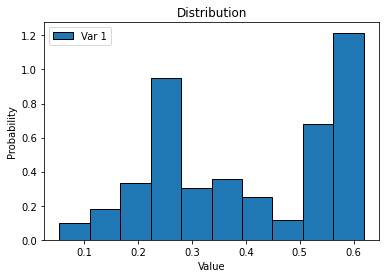

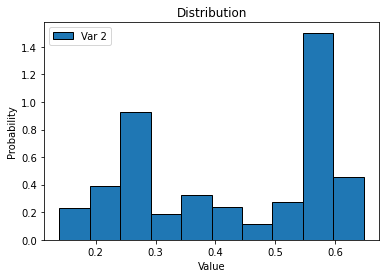

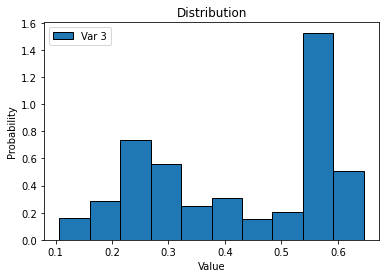

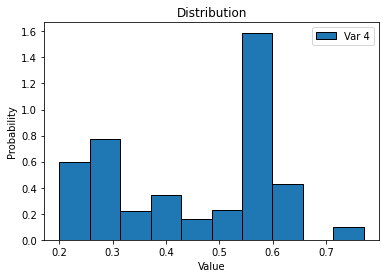

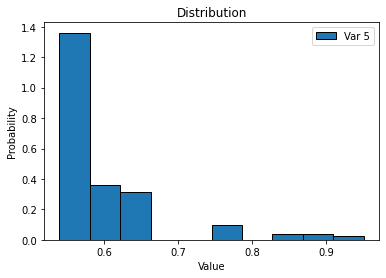

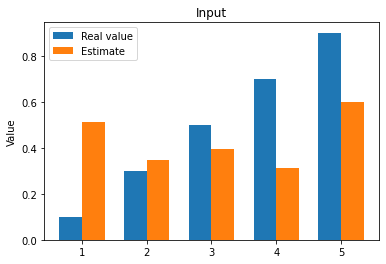

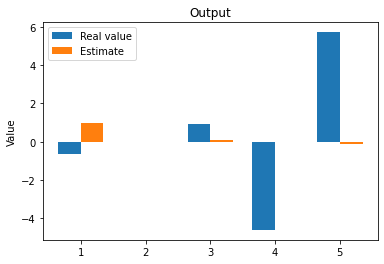

********************  # Variance = 0.1  ********************
********************  # Steps = 800  ********************
Sample 800 / 800

Average acceptance rate: 0.095 MCMC scale: 0.052858055936922915 

(0, 5, 600)
(5, 600)
(1, 5, 600)
********************  # Mean values = [0.55841546 0.44078749 0.33516351 0.26239888 0.90283216]  ********************
********************  # ESS values = [10.50144353  1.8432794  14.69125757 25.23381404  4.39974883]  ********************
********************  # Rhat values = [10.50144353  1.8432794  14.69125757 25.23381404  4.39974883]  ********************
Sample 800 / 800

Average acceptance rate: 0.17166666666666666 MCMC scale: 0.029493005722739635 

(1, 5, 600)
(5, 600)
(1, 5, 600)
********************  # Mean values = [0.54932686 0.38520096 0.38459637 0.26423764 0.73528935]  ********************
********************  # ESS values = [10.03748185  7.45274991 14.47654292 25.0326588  19.86763119]  ********************
********************  # Rhat values

KeyboardInterrupt: 

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelHF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

In [ ]:
# A_HF=Model(forward=modelHF.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_HF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# num_bins = 10

# for sd in proposal_sds:
#     print(                f"********************  # Variance = {sd}  ********************"
#                 )
#     y_HF=Gaussian(mean=A_HF(x_HF),cov=sd)
#     y_obs=y_HF(x_HF=real_x).sample()
#     posterior_HF=JointDistribution(y_HF,x_HF)(y_HF=y_obs)
#     x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

#     for N in n_samples:
#         print(                f"********************  # Steps = {N}  ********************"
#                 )
#         MHsampler_HF=MH(posterior_HF,x0=x_init)
#         estimates=np.empty((x_init.shape[0],0))
#         chains=np.empty((0,x_init.shape[0],N))
#         post=np.empty((x_init.shape[0],0))
#         for i in range(chain_length):
#                 samplesMH_HF=MHsampler_LF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#                 estimates=np.column_stack((estimates,samplesMH_HF.mean()[:, np.newaxis]))
#                 # chains=np.concatenate(chains, samplesMH_LF.samples)
#                 chains = np.concatenate((chains, np.expand_dims(samplesMH_HF.samples, axis=0)), axis=0)

#                 post=np.concatenate((post,samplesMH_HF.samples),axis=1)
        
#         print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
#                 )
          
#         for num in range(post.shape[0]):        
#                 bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
#                 hist, _ = np.histogram(post, bins=bin_edges)
#                 hist=hist/post.shape[1]
#                 bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#                 plt.figure()
#                 plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

#                 plt.xlabel('Value')
#                 plt.ylabel('Probability')
#                 plt.title('Distribution')
#                 plt.legend()
#                 plt.show()
                
#                 plt.figure()
#                 plt.plot(np.mean(chains,axis=(0,2)))
#                 plt.xlabel('Step')
#                 plt.title(f'Averaged chain var {num+1}')
#                 plt.show()

                
   

### MultiFidelity

********************  # Variance = 3.0  ********************
********************  # Steps = 400  ********************
Sample 400 / 400

Average acceptance rate: 0.29 MCMC scale: 0.09976351108197307 

********************  # Mean values = [0.28315377 0.37603594 0.42254132 0.18793097 0.49835568]  ********************
Sample 400 / 400

Average acceptance rate: 0.095 MCMC scale: 0.04816975181112406 

********************  # Mean values = [0.42470448 0.60825009 0.46135071 0.47410906 0.69947676]  ********************
Sample 400 / 400

Average acceptance rate: 0.265 MCMC scale: 0.09233722793820077 

********************  # Mean values = [0.44231673 0.50312461 0.44754131 0.43087227 0.6358166 ]  ********************
Sample 400 / 400

Average acceptance rate: 0.09 MCMC scale: 0.05968597779643239 

********************  # Mean values = [0.40409516 0.52143617 0.36514812 0.35674457 0.48011321]  ********************


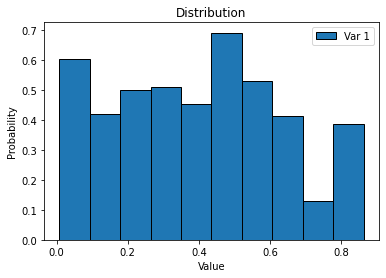

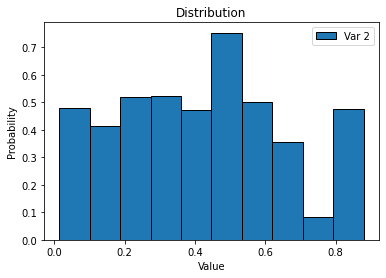

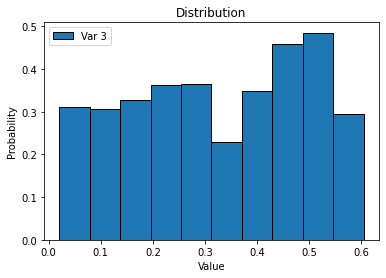

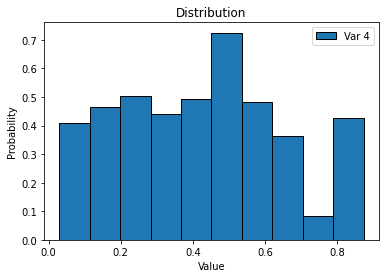

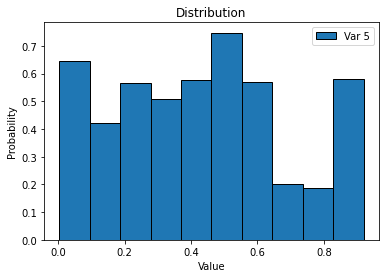

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 7.234591301188719  ********************
[[ 1.81237712e-02  1.68258130e-02  1.53381192e-02  1.38132429e-02
   1.25057655e-02  1.14506216e-02  1.05647118e-02  9.74821689e-03
   8.62137452e-03  7.48312367e-03  6.51193335e-03  5.70731809e-03
   5.13693115e-03  4.75206621e-03  4.70770536e-03  4.42897760e-03
   4.07080504e-03  3.64704140e-03  2.99404581e-03  2.41787773e-03
   1.93316380e-03  1.53259039e-03  1.06534616e-03  4.58229143e-04
  -2.35546840e-04 -9.00482411e-04 -1.53448122e-03 -2.22246725e-03
  -2.81895243e-03 -3.24769092e-03 -3.70990805e-03 -4.17115496e-03
  -4.84675716e-03 -5.42685813e-03 -5.93232318e-03 -6.29712722e-03
  -6.37978674e-03 -6.03025352e-03 -5.80016364e-03 -5.76349897e-03
  -5.91896309e-03 -6.13350563e-03 -6.43066290e-03 -6.55312396e-03
  -6.48583649e-03 -6.43946437e-03 -6.32477034e-03 -6.29180979e-03
  -6.44295385e-03 -6.46842446e-03 -6.34544273e-03 -5.87468882e-03
  -5.46912011e-03 -5.07537655e-03 -4.70368001e-03 -4.44484206e-03

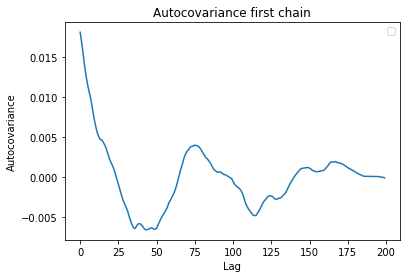

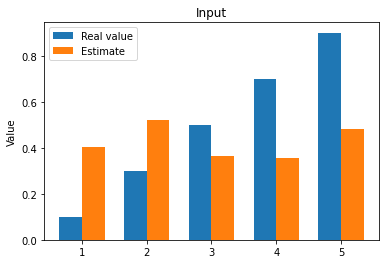

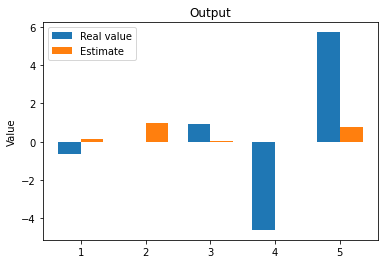

********************  # Variance = 3.0  ********************
********************  # Steps = 800  ********************
Sample 800 / 800

Average acceptance rate: 0.225 MCMC scale: 0.06753176001614201 

********************  # Mean values = [0.20517941 0.46157121 0.29682259 0.75023431 0.248081  ]  ********************
Sample 800 / 800

Average acceptance rate: 0.21 MCMC scale: 0.08842441231548047 

********************  # Mean values = [0.21646802 0.3700027  0.34134718 0.75284288 0.36036308]  ********************
Sample 800 / 800

Average acceptance rate: 0.20333333333333334 MCMC scale: 0.06668853212198682 

********************  # Mean values = [0.3895183  0.30209473 0.34977535 0.5541694  0.30118249]  ********************
Sample 800 / 800

Average acceptance rate: 0.16166666666666665 MCMC scale: 0.05358890758327038 

********************  # Mean values = [0.38176716 0.30195896 0.33496231 0.45393995 0.23382665]  ********************


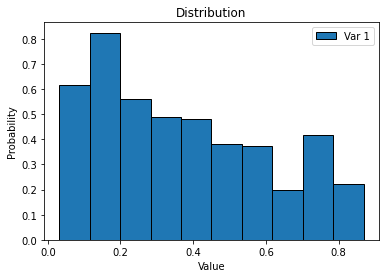

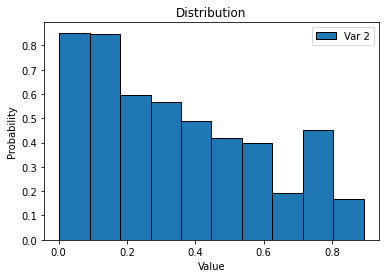

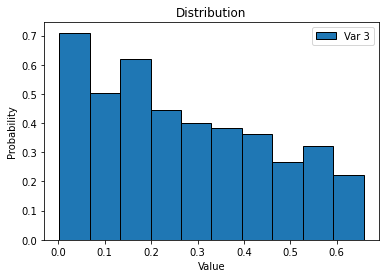

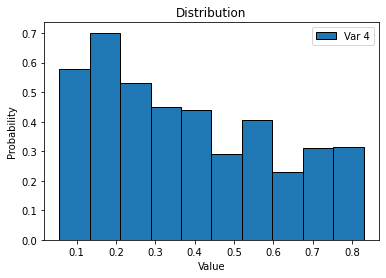

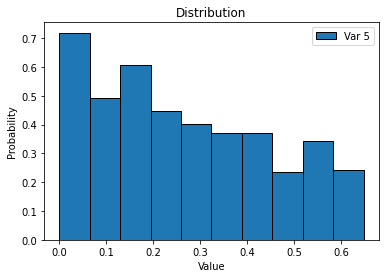

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 6.626733339983681  ********************
[[ 8.57947101e-03  8.18388805e-03  7.88188944e-03 ... -2.47382276e-05
  -1.39066326e-05 -6.95331630e-06]
 [ 1.06783923e-02  9.92611798e-03  9.24241752e-03 ... -1.13581503e-04
  -6.97827832e-05 -1.79168012e-05]
 [ 8.94204560e-03  8.64051215e-03  8.27917025e-03 ...  9.97038296e-06
   6.64692197e-06  3.32346099e-06]
 [ 4.15111691e-02  4.11997241e-02  4.08927978e-02 ...  1.85547094e-04
   1.23698063e-04  6.18490314e-05]]


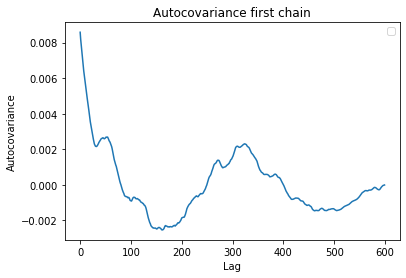

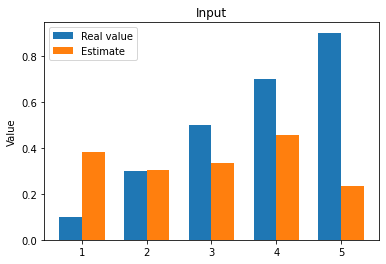

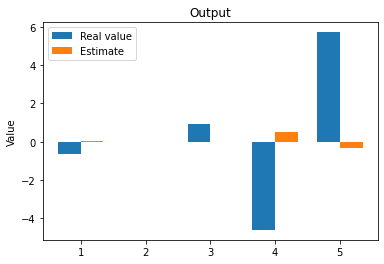

********************  # Variance = 3.0  ********************
********************  # Steps = 1200  ********************
Sample 1200 / 1200

Average acceptance rate: 0.098 MCMC scale: 0.04156030315957811 

********************  # Mean values = [0.87359392 0.39467714 0.2105442  0.28261518 0.91460057]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.129 MCMC scale: 0.060155049478585645 

********************  # Mean values = [0.65426107 0.45478617 0.23635258 0.26188252 0.91441236]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.249 MCMC scale: 0.08483447581831463 

********************  # Mean values = [0.53947529 0.4111813  0.22841849 0.42040874 0.77216229]  ********************
Sample 1200 / 1200

Average acceptance rate: 0.129 MCMC scale: 0.05359994818371124 

********************  # Mean values = [0.50862635 0.44207326 0.30284007 0.49596713 0.80783881]  ********************


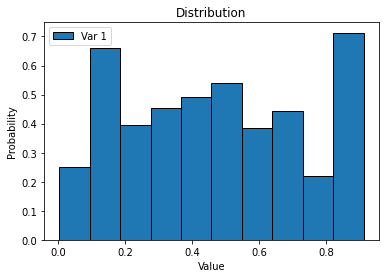

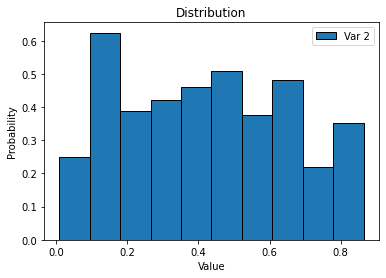

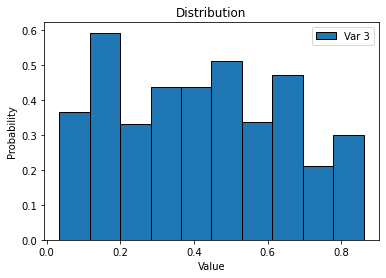

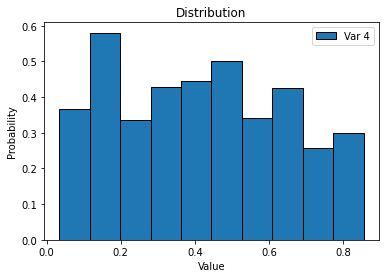

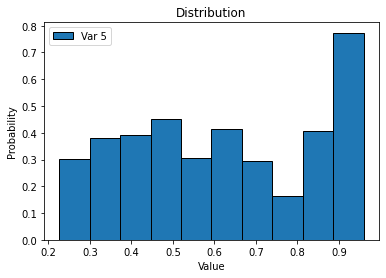

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


********************  # ESS values = 6.557940195234083  ********************
[[ 2.15314104e-04  1.95121300e-04  1.75339018e-04 ... -7.91685053e-08
  -5.27790035e-08 -2.63895018e-08]
 [ 1.72456764e-02  1.69719433e-02  1.66833070e-02 ... -3.43821566e-05
  -2.29214377e-05 -1.14607189e-05]
 [ 3.21800547e-02  3.14709649e-02  3.08620029e-02 ...  3.56569091e-06
   2.37712727e-06  1.18856364e-06]
 [ 1.14018040e-02  1.10983069e-02  1.08143809e-02 ...  6.08949390e-05
   5.46246933e-05  2.73123466e-05]]


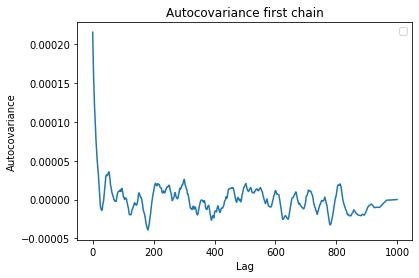

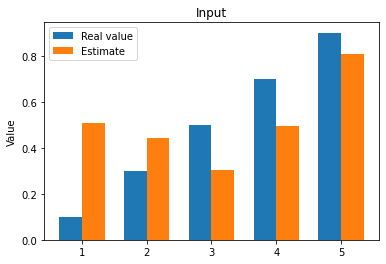

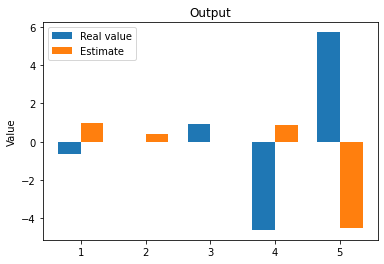

In [19]:
#proposal_sds=proposal_sds[2:3]

for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=final_model.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

In [ ]:
# A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# num_bins = 10

# for sd in proposal_sds:
#     print(                f"********************  # Variance = {sd}  ********************"
#                 )
#     y_MF=Gaussian(mean=A_MF(x_MF),cov=sd)
#     y_obs=y_MF(x_MF=real_x).sample()
#     posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
#     x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

#     for N in n_samples:
#         print(                f"********************  # Steps = {N}  ********************"
#                 )
#         MHsampler_MF=MH(posterior_MF,x0=x_init)
#         estimates=np.empty((x_init.shape[0],0))
#         chains=np.empty((0,x_init.shape[0],N))
#         post=np.empty((x_init.shape[0],0))
#         for i in range(chain_length):
#                 samplesMH_MF=MHsampler_MF.sample_adapt(N,int(N/2))    # N: number of "real" steps Nb: number of burn-in steps # total nb of steps is the sum of the two
#                 estimates=np.column_stack((estimates,samplesMH_MF.mean()[:, np.newaxis]))
#                 # chains=np.concatenate(chains, samplesMH_LF.samples)
#                 chains = np.concatenate((chains, np.expand_dims(samplesMH_MF.samples, axis=0)), axis=0)

#                 post=np.concatenate((post,samplesMH_MF.samples),axis=1)
        
#         print(                f"********************  # Mean values = {estimates.mean(axis=1)}  ********************"
#                 )
          
#         for num in range(post.shape[0]):        
#                 bin_edges = np.linspace(np.min(post[num,:]), np.max(post[num,:]), num_bins + 1)
#                 hist, _ = np.histogram(post, bins=bin_edges)
#                 hist=hist/post.shape[1]
#                 bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#                 plt.figure()
#                 plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')

#                 plt.xlabel('Value')
#                 plt.ylabel('Probability')
#                 plt.title('Distribution')
#                 plt.legend()
#                 plt.show()
                
#                 plt.figure()
#                 plt.plot(np.mean(chains,axis=(0,2)))
#                 plt.xlabel('Step')
#                 plt.title(f'Averaged chain var {num+1}')
#                 plt.show()

                
   

Sample 600 / 600

Average acceptance rate: 0.13666666666666666 MCMC scale: 0.04012786795875335 



array([0.23507817, 0.53022968, 0.51405922, 0.21669816, 0.52535724])

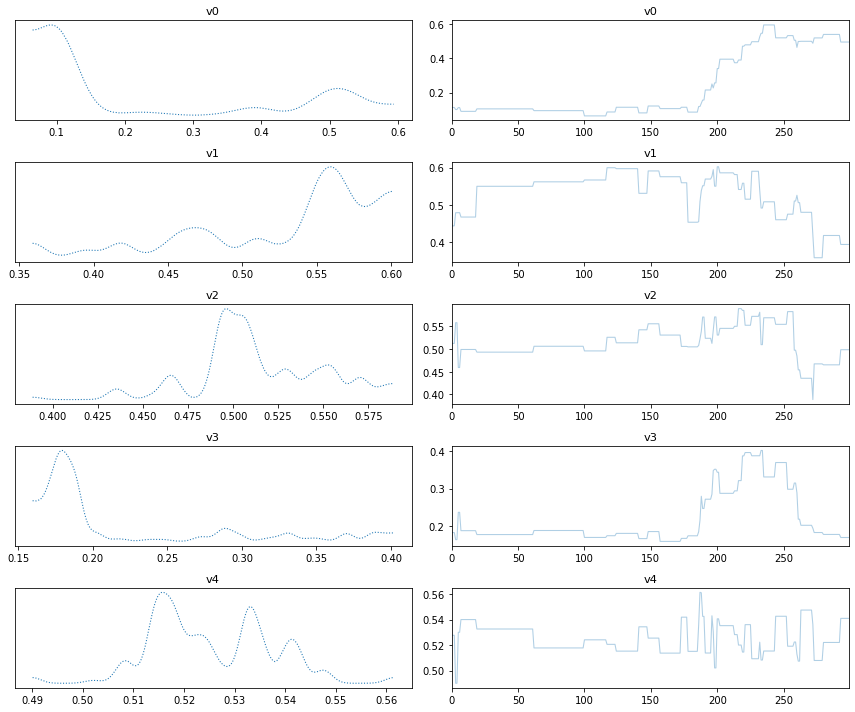

In [ ]:
# CODE SIMPLE

# A_MF=Model(forward=final_model.prediction, range_geometry=Continuous1D(5), domain_geometry=Continuous1D(5))
# x_MF=Uniform(np.array([0.,0.,0.,0.,0.]),np.array([1.,1.,1.,1.,1.]))
# y_MF=Gaussian(mean=A_MF(x_MF),cov=proposal_sd)
# y_obs=y_MF(x_MF=real_x).sample()
# posterior_MF=JointDistribution(y_MF,x_MF)(y_MF=y_obs)
# x_init=np.array([initial_x,initial_x,initial_x,initial_x,initial_x])

# MHsampler_MF=MH(posterior_MF,x0=x_init)
# samplesMH_MF=MHsampler_MF.sample_adapt(n_samples,n_samples)

# samplesMH_MF.plot_trace()
# samplesMH_MF.mean()
# samplesMH_MF.compute_ess()
# samplesMH_MF.plot_autocorrelation()

# Discontinuous Benchmark

In [ ]:
lowfid = lambda x: (0.5*(6.*x-2.)**2*np.sin(12.*x-4)+10.*(x-0.5)-5.)*(x<0.5) + (3+0.5*(6.*x-2)**2*np.sin(12.*x-4)+10*(x-0.5)-5.)*(x>0.5)
highfid = lambda x: (2*lowfid(x)- 20*x+20)*(x<0.5) + (4+2*lowfid(x)- 20*x+20)*(x>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

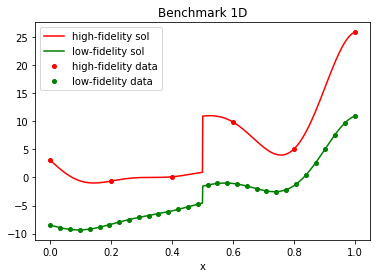

In [ ]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

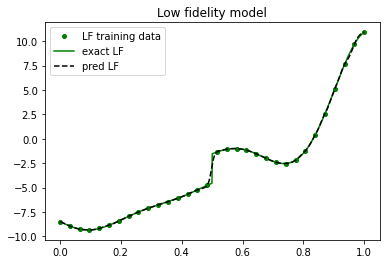

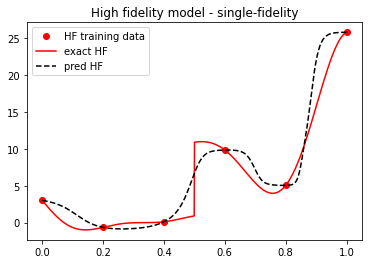

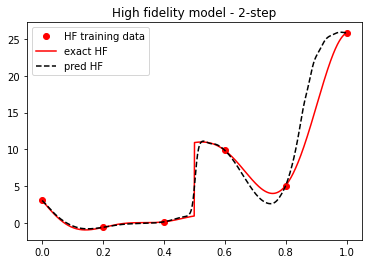

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [ ]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = np.array([400,800,1200])  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sds = np.array([0.1,0.25,0.5,0.75,1.]) # Standard deviation for the proposal distribution
chain_length=10

### Low Fidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelLF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

### High Fidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelHF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

### MultiFidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=final_model.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

# Nonlinear correlation

OBS: "periodic" case seems not to work

In [ ]:
lowfid = lambda x: np.sin(8*np.pi*x)
highfid = lambda x: (x-np.sqrt(2))*lowfid(x)**2
Nhf = 15
Nlf = 64
N = Nhf + Nlf
xhf = np.linspace(0,1,Nhf)
xlf = np.linspace(0,1,Nlf)
x_test = np.linspace(0,1,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 3000
NepoHF = 3000

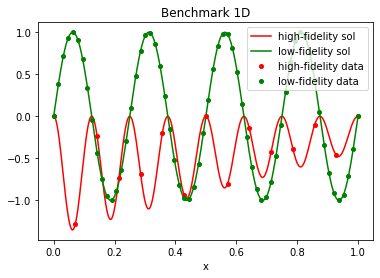

In [ ]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)

## High fidelity model

In [ ]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)

## 2 Step model

In [ ]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

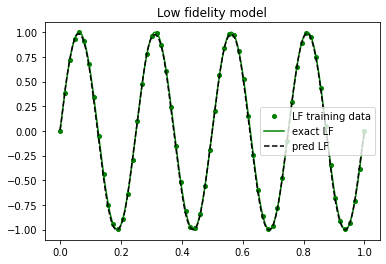

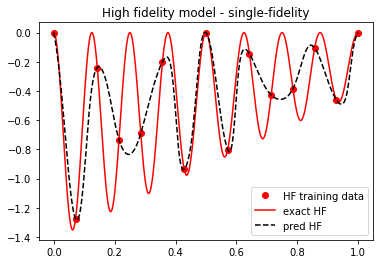

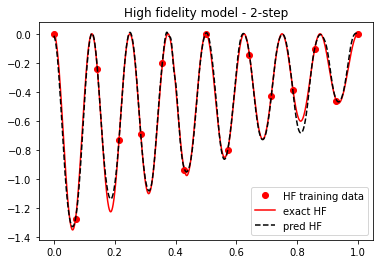

In [ ]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC

In [ ]:
real_x = np.array([0.1,0.3,0.5,0.7,0.9])
observed_output = highfid(real_x)

# Set parameters for the MCMC
n_samples = 300  # Number of samples
initial_x = 0.5 # Initial value for x
proposal_sd = 0.3 # Standard deviation for the proposal distribution

### Low Fidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelLF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

### High Fidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=modelHF.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()

### MultiFidelity

In [ ]:
for sd in proposal_sds:
    for N in n_samples:
        
        print(                f"********************  # Variance = {sd}  ********************")
        print(                f"********************  # Steps = {N}  ********************"
                 )

        estimates=final_model.inverse(x_real=real_x,number_chains=chain_length, N=N, burn_in=int(n_samples[0]/2), proposal_sd=sd,x_init=initial_x)
        
        values2 = estimates.mean(axis=1)
        values1 =real_x

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Input')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()
        
        # Dati di esempio
        values2 = highfid(estimates.mean(axis=1))
        values1 =observed_output

        # Unire i valori in un unico array
        values = np.vstack((values1, values2))

        # Creare categorie in base alla lunghezza di values
        categories = np.arange(1, values.shape[1] + 1)

        # Larghezza delle colonne
        bar_width = 0.35

        # Posizioni delle colonne
        bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

        # Creazione del plot
        for i in range(values.shape[0]):
            plt.bar(bar_positions[i], values[i, :], width=bar_width)


        plt.ylabel('Value')
        plt.title('Output')
        plt.xticks(categories)
        plt.legend(["Real value", "Estimate"])


        # Mostra il plot
        plt.show()